In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
pd.set_option('display.max_columns', None)

In [2]:
raw_data = pd.read_csv('BankChurners.csv')
data = raw_data.drop(['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                      'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1)
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


## Data Cleaning

### Checking for duplicates

In [3]:
# check if duplicates exist
data.duplicated().sum()

np.int64(0)

### Outliers

In [4]:
# Check Total_Amt_Chng_Q4_Q1 variable where value > 2.0
data[data['Total_Amt_Chng_Q4_Q1'] > 2.0]

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,5,2,0,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113
12,710599683,Existing Customer,56,M,1,College,Single,$80K - $120K,Blue,36,3,6,0,11751.0,0,11751.0,3.397,1539,17,3.250,0.000
46,789172683,Existing Customer,56,M,2,Doctorate,Married,$60K - $80K,Blue,45,6,2,0,2283.0,1430,853.0,2.316,1741,27,0.588,0.626
47,738406533,Existing Customer,59,M,1,Doctorate,Married,$40K - $60K,Blue,52,3,2,2,2548.0,2020,528.0,2.357,1719,27,1.700,0.793
58,711427458,Existing Customer,44,F,5,Graduate,Married,Unknown,Blue,35,4,1,2,6273.0,978,5295.0,2.275,1359,25,1.083,0.156
154,795232683,Existing Customer,53,F,1,College,Married,Less than $40K,Blue,47,4,2,3,2154.0,930,1224.0,2.121,1439,26,1.364,0.432
177,717296808,Existing Customer,67,F,1,Graduate,Married,Less than $40K,Blue,56,4,3,2,3006.0,2517,489.0,2.053,1661,32,1.000,0.837


In [5]:
# Check Total_Ct_Chng_Q4_Q1 variable where value > 2.25
data[data['Total_Ct_Chng_Q4_Q1'] > 2.25]

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
12,710599683,Existing Customer,56,M,1,College,Single,$80K - $120K,Blue,36,3,6,0,11751.0,0,11751.0,3.397,1539,17,3.250,0.000
30,778348233,Existing Customer,53,M,3,Unknown,Married,$80K - $120K,Blue,33,3,2,3,2753.0,1811,942.0,0.977,1038,25,2.571,0.658
68,711314058,Existing Customer,49,M,2,Graduate,Married,$60K - $80K,Blue,32,2,2,2,1687.0,1107,580.0,1.715,1670,17,2.400,0.656
113,718619883,Existing Customer,54,F,0,Uneducated,Married,Less than $40K,Blue,36,2,2,2,1494.0,706,788.0,1.674,1305,24,3.000,0.473
146,716104983,Existing Customer,41,F,2,Graduate,Single,Less than $40K,Blue,32,6,3,2,2250.0,2117,133.0,1.162,1617,31,2.875,0.941
158,718759833,Existing Customer,44,F,2,Uneducated,Married,Unknown,Silver,35,4,3,2,32643.0,0,32643.0,1.300,1058,24,2.429,0.000


**NOTE**<br>
Since none of these observations seem to be obvious data mistakes, we will not remove them. Also, since all of these observations are 'similar' across most variables (all of them are existing customers, most above 40 years old, mostly Blue Card Category), we may instead change the maximum of these 2 variables to a more moderate value in order to atone for their effect on future modelling

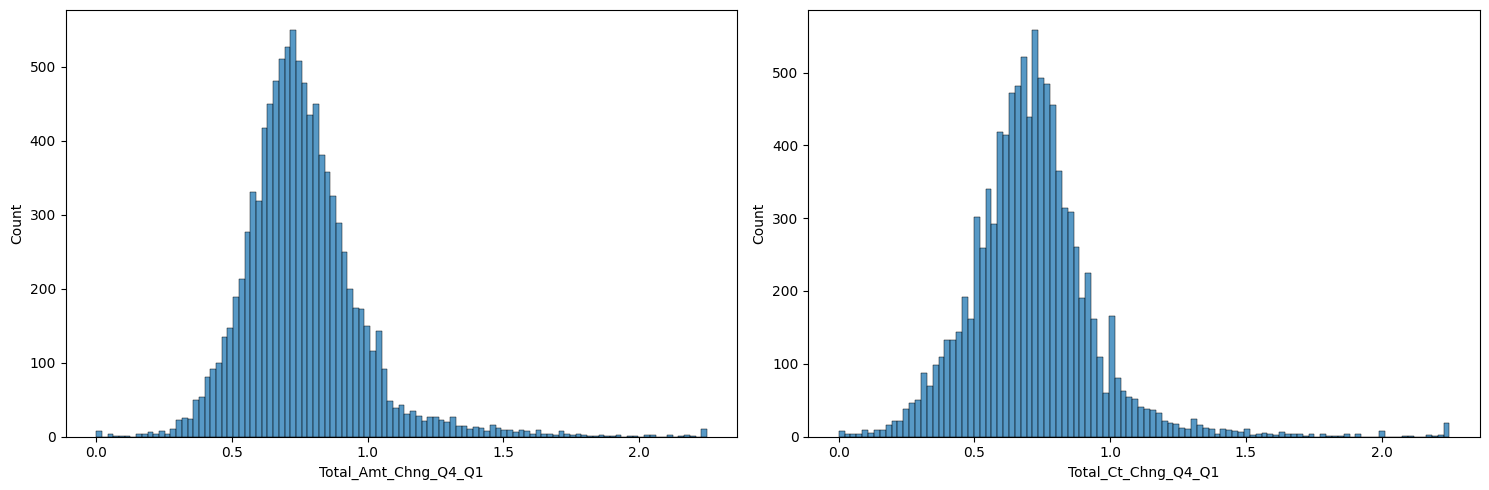

In [6]:
# change max Total_Amt_Chng_Q4_Q1 to 2.25
data['Total_Amt_Chng_Q4_Q1'] = data['Total_Amt_Chng_Q4_Q1'].apply(lambda x: 2.25 if x > 2.25 else x)

# change max Total_Ct_Chng_Q4_Q1 to 2.25
data['Total_Ct_Chng_Q4_Q1'] = data['Total_Ct_Chng_Q4_Q1'].apply(lambda x: 2.25 if x > 2.25 else x)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

for i, var in enumerate(['Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1']):
    sns.histplot(data[var], ax=axes[i])

plt.tight_layout()
plt.show()

### Data transformation

In [7]:
variables_to_transform = ['Credit_Limit', 'Avg_Open_To_Buy', 'Avg_Utilization_Ratio']
transformed_variables = []
for var in variables_to_transform:
    # log transformation 
    data[f'{var}_Log'] = data[var].apply(lambda x: np.log(x) if x > 0 else 0)
    transformed_variables.append(f'{var}_Log')

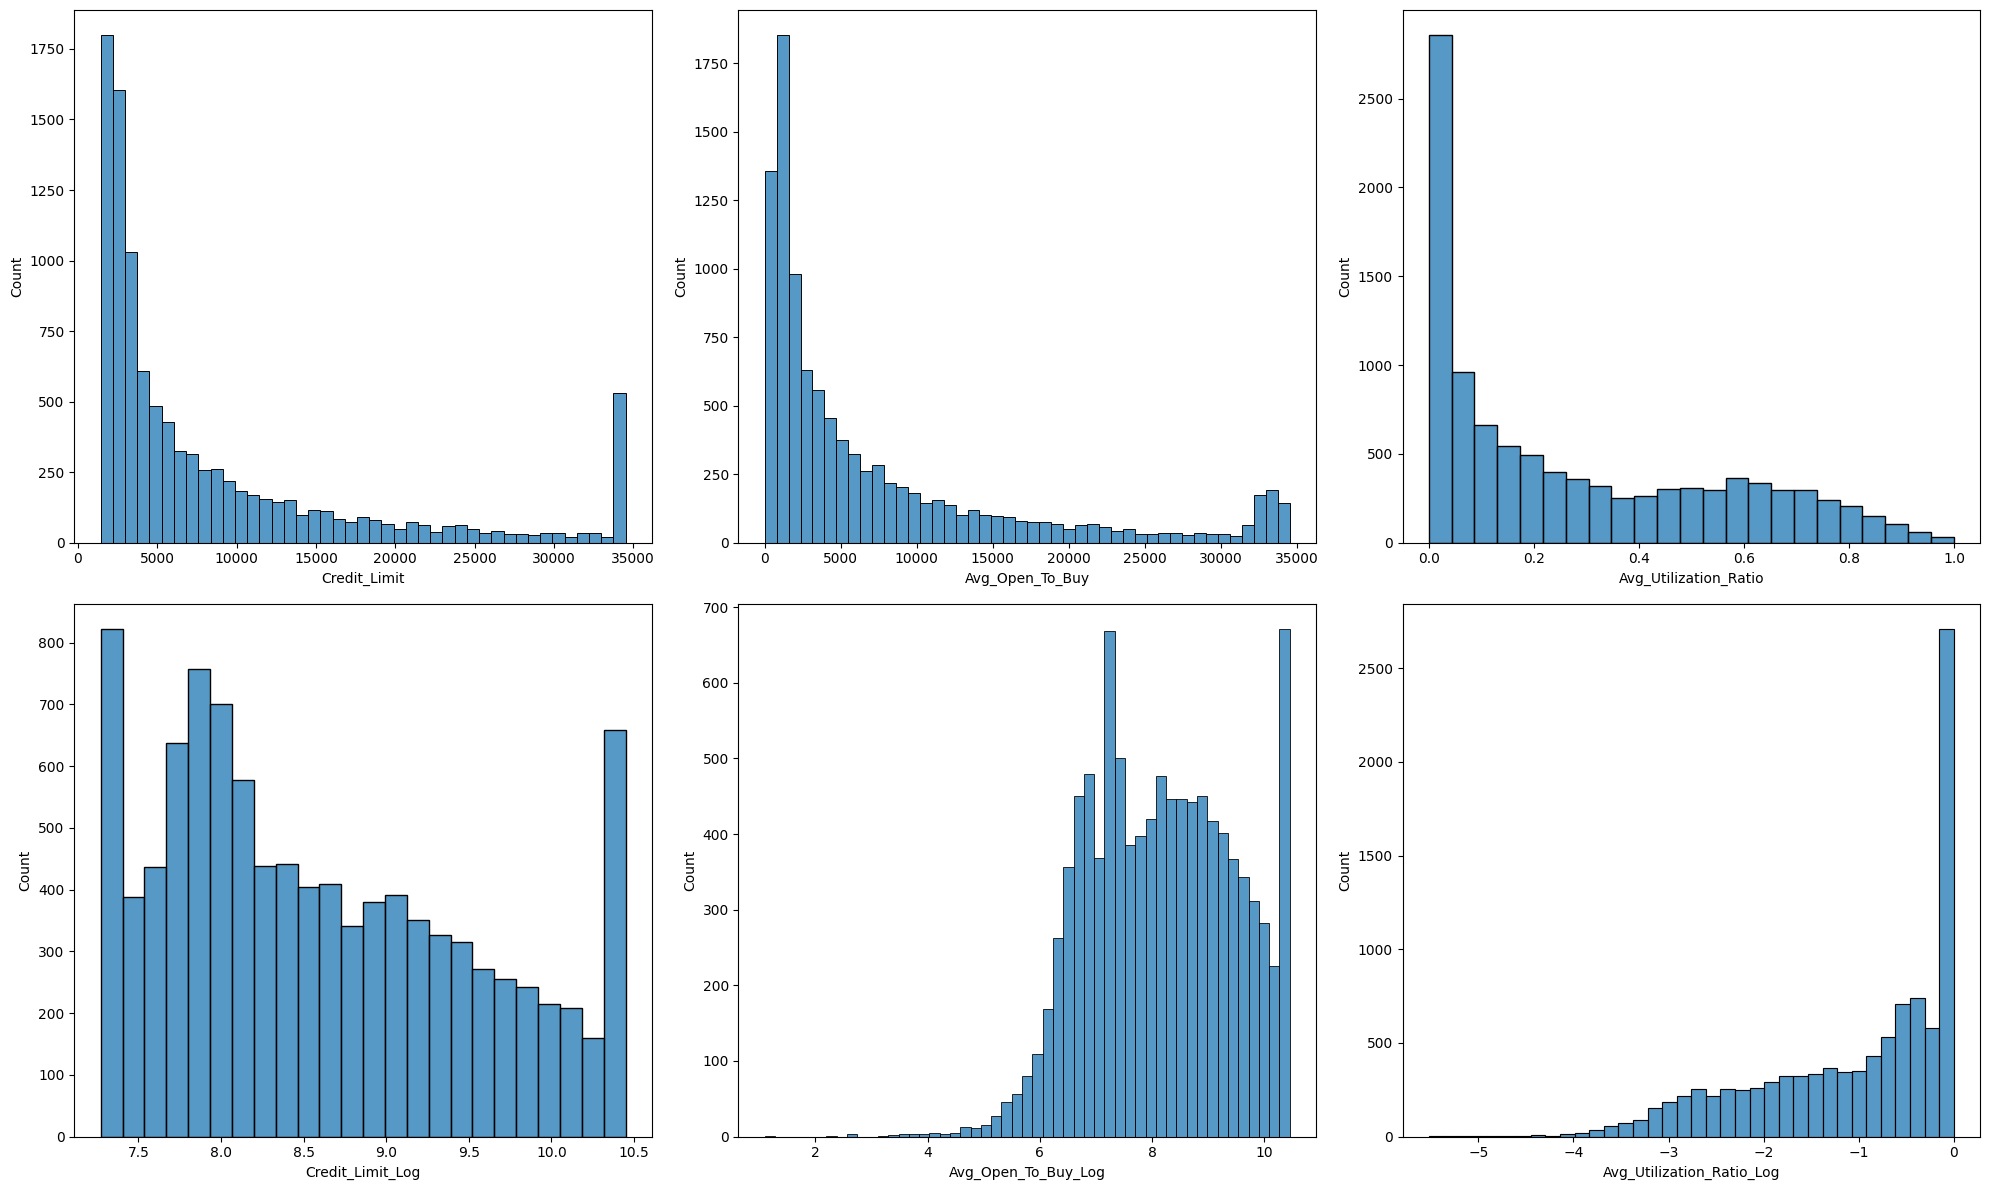

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate([*variables_to_transform, *transformed_variables]):
    sns.histplot(data[var], ax=axes[i])

plt.tight_layout()
plt.show()

**NOTE**<br>
As log transforming the variables Avg_Open_To_Buy and Avg_Utilization_Ratio failed to correct their skewness, instead it only changed them from right-skewed to left-skewed, we will keep their original versions.

In [9]:
# drop Avg_Open_To_Buy', 'Avg_Utilization_Ratio
data.drop(['Avg_Open_To_Buy_Log', 'Avg_Utilization_Ratio_Log'], axis=1, inplace=True)
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Credit_Limit_Log
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,9.448648
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,2.250,0.105,9.018695
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.250,1887,20,2.250,0.000,8.136811
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.250,0.760,8.105609
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.250,0.000,8.458716


### Encodings

**Binary encoded variables**
- Attrition Flag
- Gender <br><br>

**One-hot encoded variables (nominal variables)**
- Marital Status <br><br>

**Label encoded variables (ordinal variables)**
- Education Level
- Income Category
- Card Category

In [10]:
# One-hot encoding the nominal features
binary_features = ['Attrition_Flag', 'Gender']
binary_categories = [
    ['Existing Customer', 'Attrited Customer'],
    ['F', 'M'],
]
binary_encoder = OrdinalEncoder(categories=binary_categories, 
                                handle_unknown='use_encoded_value', 
                                unknown_value=-1)

binary_array = binary_encoder.fit_transform(data[binary_features])
encoded_binary = pd.DataFrame(binary_array, 
                              columns=binary_features, 
                              index=data.index).astype(int)

# One-hot encode Marital_Status 
marital_encoder = OneHotEncoder(categories=[['Divorced', 'Married', 'Single']],
                                sparse_output=False,
                                handle_unknown='ignore')

marital_array = marital_encoder.fit_transform(data[['Marital_Status']])
marital_cols = marital_encoder.get_feature_names_out(['Marital_Status'])

encoded_marital = pd.DataFrame(marital_array, 
                               columns=marital_cols, 
                               index=data.index).astype(int)

# Ordinal encode the remaining ordered features
ordinal_features = ['Education_Level', 'Income_Category', 'Card_Category']
ordinal_categories = [
    ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate'],
    ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +'],
    ['Blue', 'Silver', 'Gold', 'Platinum'],
]
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1)
ord_array = ordinal_encoder.fit_transform(data[ordinal_features])
encoded_ordinal = pd.DataFrame(ord_array, columns=ordinal_features, index=data.index).astype(int)

# Keep only the encoded versions
encoded_data = data.drop(columns=binary_features + ['Marital_Status'] + ordinal_features)
data = pd.concat([encoded_data, encoded_binary, encoded_marital, encoded_ordinal], axis=1)
data.head()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Credit_Limit_Log,Attrition_Flag,Gender,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Education_Level,Income_Category,Card_Category
0,768805383,45,3,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,9.448648,0,1,0,1,0,2,3,0
1,818770008,49,5,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,2.250,0.105,9.018695,0,0,0,0,1,4,1,0
2,713982108,51,3,36,4,1,0,3418.0,0,3418.0,2.250,1887,20,2.250,0.000,8.136811,0,1,0,1,0,4,4,0
3,769911858,40,4,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.250,0.760,8.105609,0,0,0,0,0,2,1,0
4,709106358,40,3,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.250,0.000,8.458716,0,1,0,1,0,1,3,0


**NOTE**<br>
As the original variables won't be useful for non-tree models, and for tree-models it is indifferent wether they are encoded or not, we kept only the encoded versions

### Scaling

Some variables show presence of outliers that should not necessairily be removed, so we apply the robust scaler to atone their effect

In [11]:
keep_both = [
    "Education_Level",
    "Income_Category",
    "Card_Category",
    "Gender",
]

# All other columns are to be replaced (Excluding CLIENTNUM or Attrition_Flag)
num_cols = [col for col in data.columns
            if col not in keep_both and col not in ["CLIENTNUM", "Attrition_Flag"]]


scaler = RobustScaler()

# Scale numerical columns
data[num_cols] = scaler.fit_transform(data[num_cols])

# Create scaled duplicates for the ordinal and nominal features
for col in keep_both:
    data[f"{col}_scaled"] = scaler.fit_transform(data[[col]])
    data.drop(columns=[col], inplace=True)

data.head()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Credit_Limit_Log,Attrition_Flag,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Education_Level_scaled,Income_Category_scaled,Card_Category_scaled,Gender_scaled
0,768805383,-0.090909,0.5,0.333333,0.5,-1.0,1.0,0.956476,-0.350175,0.988927,2.627193,-1.065558,-0.694444,3.911017,-0.239583,0.699873,0,0.0,1.0,0.0,-0.333333,0.5,0.0,1.0
1,818770008,0.272727,1.5,0.888889,1.0,-1.0,0.0,0.435477,-0.289123,0.459078,3.530702,-1.008702,-0.944444,6.559322,-0.147917,0.406582,0,0.0,0.0,1.0,0.333333,-0.5,0.0,0.0
2,713982108,0.454545,0.5,0.000000,0.0,-1.0,-2.0,-0.132863,-0.895439,-0.006562,6.640351,-0.778186,-1.305556,6.559322,-0.366667,-0.194993,0,0.0,1.0,0.0,0.333333,1.0,0.0,1.0
3,769911858,-0.545455,1.0,-0.222222,-0.5,2.0,-1.0,-0.145198,0.870877,-0.313785,2.934211,-1.055115,-1.305556,6.559322,1.216667,-0.216277,0,0.0,0.0,0.0,-0.333333,-0.5,0.0,0.0
4,709106358,-0.545455,0.5,-1.666667,0.5,-1.0,-2.0,0.019618,-0.895439,0.145527,6.311404,-1.192419,-1.083333,6.559322,-0.366667,0.024594,0,0.0,1.0,0.0,-0.666667,0.5,0.0,1.0


**NOTE**<br>
We didn't scale the marital status variable as it is one-hot encoded with more than 2 categories

In [12]:
# Export data to csv
data.to_csv('processed_data.csv', index=False)